# Лабораторна робота №1 "Зменшення розмірності даних"
**Мета.** Ознайомитися з основами **зменшення розмірності даних (dimensionality reduction)** на прикладі зображень рукописних цифр із набору **MNIST**. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

## Хід роботи

### Викачати та підготувати дані
Імпортуємо необхідні бібліотеки:

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

Завантажуємо датасет, де _X_ – матриця, кожен рядок якої є розгорткою зображення, _y_ – мітки класів

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

Виведемо форму матриці _X_ і кількість унікальних міток _y_

In [3]:
print(X.shape)
print(len(np.unique(y)))

(70000, 784)
10


Знайдемо індекси кожної унікальної цифри

In [4]:
unique_indexes = np.unique(y, return_index=True)[1]
print(unique_indexes)

[ 1  3  5  7  2  0 13 15 17  4]


Отримаємо відповідні рядки та змінимо форму на 28x28 пікселів

In [5]:
unique_images = X[unique_indexes].reshape(-1, 28, 28)
print(unique_images.shape)

(10, 28, 28)


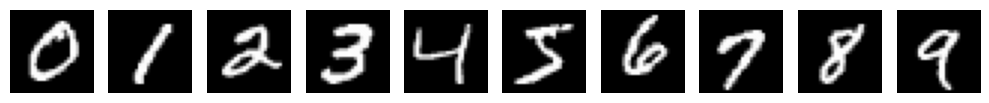

In [6]:
fig, axes = plt.subplots(1, 10, figsize=(10, 2))

for i in range(len(unique_images)):
    img = unique_images[i]
    axes[i].imshow(img, cmap="gray")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Реалізувати метод головних компонент (PCA)
Реалізуємо PCA із кількістю компонент n_components=3

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)
print(f"Розмірність матриці проєкцій X_pca: {X_pca.shape}")

Розмірність матриці проєкцій X_pca: (70000, 3)


Як бачимо, розмірність матриці проєкцій відповідає очікуваній. Тепер виведемо відсоток поясненої дисперсії:

In [9]:
explained_variance = pca.explained_variance_ratio_

print("Відсоток поясненої дисперсії для кожної компоненти:")
for i, variance in enumerate(explained_variance):
    print(f"Головна компонента {i+1} (PC{i+1}): {variance:.2%}")

print(f"\nЗагальний відсоток поясненої дисперсії трьома компонентами: {np.sum(explained_variance):.2%}")

Відсоток поясненої дисперсії для кожної компоненти:
Головна компонента 1 (PC1): 9.75%
Головна компонента 2 (PC2): 7.16%
Головна компонента 3 (PC3): 6.15%

Загальний відсоток поясненої дисперсії трьома компонентами: 23.05%


### Візуалізувати дані у просторі перших трьох компонент
Побудуємо 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних. Точки зафарбуємо відповідно до класу цифри.

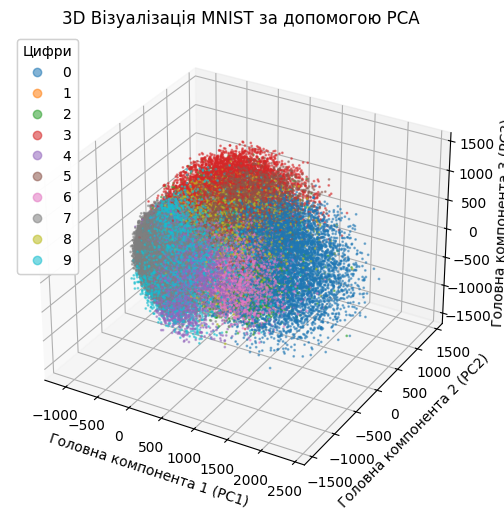

In [10]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Точковий графік
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y.astype(int), cmap='tab10', s=1, alpha=0.5)

# Легенда з номерами цифр
legend1 = ax.legend(*scatter.legend_elements(), title="Цифри", loc="upper left")
ax.add_artist(legend1)

ax.set_xlabel('Головна компонента 1 (PC1)')
ax.set_ylabel('Головна компонента 2 (PC2)')
ax.set_zlabel('Головна компонента 3 (PC3)')
ax.set_title('3D Візуалізація MNIST за допомогою PCA')

plt.show()

Як бачимо, у трьох просторах ми можемо побачити деяку кластеризацію, проте, через низьку частку дисперсії (23.05%), складно відділити окремі цифри.

### Реконструкція зображень після зменшення розмірності
Відновимо дані з простору трьох компонент у оригінальний 784-вимірний простір

In [11]:
X_restored = pca.inverse_transform(X_pca)
print(X_restored.shape)

(70000, 784)


Виведемо отримані зображення:

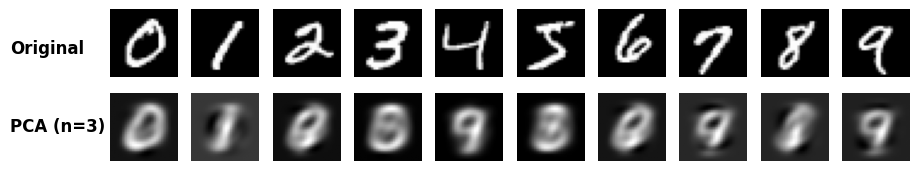

In [12]:
unique_images_restored = X_restored[unique_indexes].reshape(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(10, 2))
for i in range(10):
    # Виведення оригінального зображення
    axes[0, i].imshow(unique_images[i], cmap="gray")
    axes[0, i].axis('off')

    # Виведення реконструйованого зображення
    axes[1, i].imshow(unique_images_restored[i], cmap="gray")
    axes[1, i].axis('off')
    
fig.text(0, 0.68, 'Original', va='center', fontsize=12, fontweight='bold')
fig.text(0, 0.29, 'PCA (n=3)', va='center', fontsize=12, fontweight='bold')

plt.subplots_adjust(left=0.1)
plt.show()


Можна прослідкувати деяку схожість реконструйованих зображень з оригінальними, проте деякі цифри надто схожі. Суб'єктивно я б розбив відновленні зображення на чотири кластери: {0, 2, 6}, {1}, {3, 5, 8}, {4, 7, 9}. Таким чином, одиниця є найбільш відмінною з усіх цифр.

### Проаналізувати залежність між помилкою реконструкції та кількістю компонент

Дізнаємося середньоквадратичну помилку для 3 компонент.

In [13]:
from sklearn.metrics import mean_squared_error

In [14]:
mse_value = mean_squared_error(X, X_restored)
print(f"Середньоквадратична помилка (MSE) для 3 компонент: {mse_value:.2f}")
rmse_value = np.sqrt(mse_value)
print(f"Середньоквадратичне відхилення (RMSE) для 3 компонент: {rmse_value:.2f}")

Середньоквадратична помилка (MSE) для 3 компонент: 3366.49
Середньоквадратичне відхилення (RMSE) для 3 компонент: 58.02


В середньому кожен піксель реконструйованого зображення відрізняється від оригінального на 58.02 значення.

Тепер дізнаємося середньоквадратичну помилку для різних класів (чисел):

In [15]:
for digit in range(10):
    mask = (y.astype(int) == digit)
    mse_digit = mean_squared_error(X[mask], X_restored[mask])
    print(f"Цифра {digit}: MSE = {mse_digit:.2f}")

Цифра 0: MSE = 3908.55
Цифра 1: MSE = 1943.66
Цифра 2: MSE = 4201.20
Цифра 3: MSE = 3444.52
Цифра 4: MSE = 3251.27
Цифра 5: MSE = 3591.74
Цифра 6: MSE = 3939.17
Цифра 7: MSE = 3107.48
Цифра 8: MSE = 3676.48
Цифра 9: MSE = 2830.95


Як бачимо, одиниця і справді має найменшу помилку, водночас двійка – найбільшу

Обчислимо MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k. Для цього спочатку знайдемо усі власні значення через $\text{PCA}(k_{max})$

In [16]:
k_max = 784

pca_max = PCA(n_components=k_max)
pca_max.fit(X)

explained_variance = pca_max.explained_variance_

print(f"Перші 5 власних значень: {explained_variance[:5]}")
print(f"Останні 5 власних значень: {explained_variance[-5:]}") 

Перші 5 власних значень: [334294.06141858 245433.42714427 210930.35458571 185337.3563191
 167691.57240407]
Останні 5 власних значень: [0. 0. 0. 0. 0.]


За формулою,
$$
\text{MSRE}(k) = \sum_{j=k+1}^d \lambda_j,
$$
де MSRE – помилка реконструкції для всіх _n_ точок.

Відповідно, для знаходження MSE кожної точки (як це було зроблено вище за допомогою функції _mean_squared_error_), розділимо значення на _n_ = _k_max_:
$$
\text{MSE}(k) = \frac{1}{n} \text{MSRE}(k)
$$

In [17]:
cummulative = np.cumsum(explained_variance) # 0 = 0, 1 = 0 + 1, etc. 
sum = cummulative[-1] # total sum

msre_values = sum - cummulative
mse_values = msre_values / 784
print(f"Перші 5 значень MSE(k): {mse_values[:5]}")
print(f"Останні 5 значень MSE(k): {mse_values[-5:]}")

Перші 5 значень MSE(k): [3948.63442176 3635.58158102 3366.53776139 3130.13807221 2916.24576047]
Останні 5 значень MSE(k): [0. 0. 0. 0. 0.]


Можемо побачити, що MSE(3) відповідає значенню, отриманому за допомогою функції _mean_squared_error_.

Відсоток поясненої дисперсії для різної кількості компонент k отримати ще простіше:

In [18]:
ev_ratios = np.cumsum(pca_max.explained_variance_ratio_)
print(f"Перші 5 значень відсотку поясненої дисперсії: {ev_ratios[:5] * 100}")
print(f"Останні 5 значень відсотку поясненої дисперсії: {ev_ratios[-5:] * 100}")

Перші 5 значень відсотку поясненої дисперсії: [ 9.74611592 16.90156051 23.05109149 28.45447602 33.34340972]
Останні 5 значень відсотку поясненої дисперсії: [100. 100. 100. 100. 100.]


Отримаємо значення для довільних кількостей компонент k та побудуємо графіки:

In [19]:
k_chosen = [2, 5, 10, 30, 100, 200, 400]
mse_chosen = mse_values[k_chosen]
ev_chosen = ev_ratios[k_chosen]

print(mse_chosen)
print(ev_chosen)

[3366.53776139 2727.89079029 2142.72633974 1145.41018713  367.75038185
  145.15866866   17.89517467]
[0.23051091 0.37648637 0.51023733 0.73819375 0.91594334 0.9668211
 0.9959097 ]


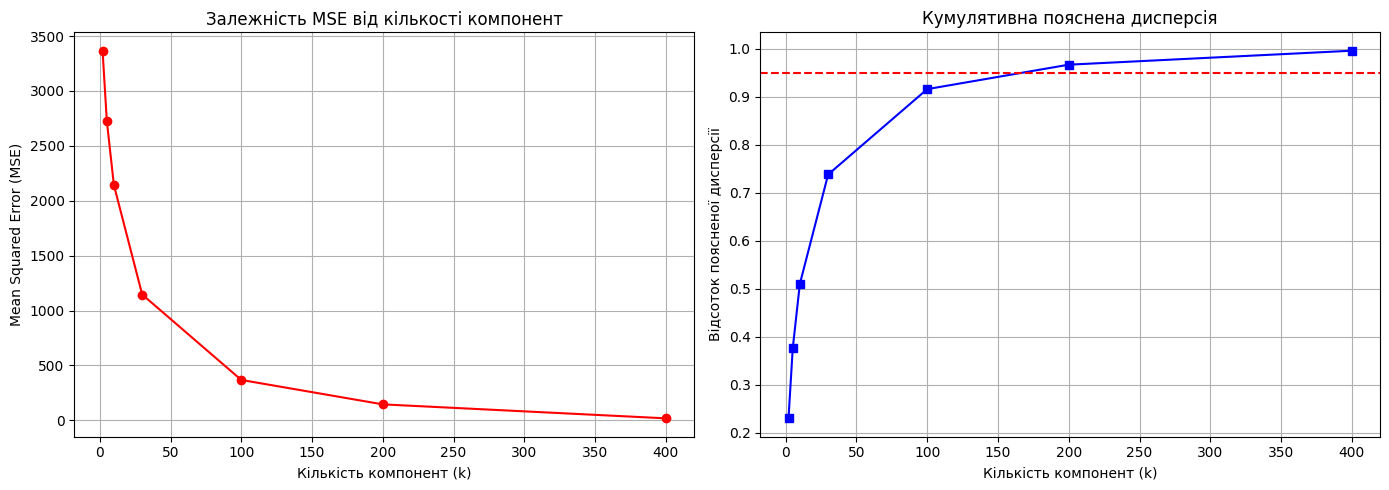

In [20]:
plt.figure(figsize=(14, 5))

# Графік MSE
plt.subplot(1, 2, 1)
plt.plot(k_chosen, mse_chosen, marker='o', color='red')
plt.title('Залежність MSE від кількості компонент')
plt.xlabel('Кількість компонент (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)

# Графік поясненої дисперсії
plt.subplot(1, 2, 2)
plt.plot(k_chosen, ev_chosen, marker='s', color='blue')
plt.axhline(y=0.95, color='red', linestyle='--') # Поріг у 95%
plt.title('Кумулятивна пояснена дисперсія')
plt.xlabel('Кількість компонент (k)')
plt.ylabel('Відсоток поясненої дисперсії')
plt.grid(True)

plt.tight_layout()
plt.show()

Наостанок знайдемо мінімальну кількість компонент для досягнення порогу в 95% поясненої дисперсії

In [21]:
k_95 = np.argmax(ev_ratios >= 0.95) + 1
print(f"Необхідна кількість компонент для 95% дисперсії: {k_95}")

Необхідна кількість компонент для 95% дисперсії: 154


## Висновки
В ході лабораторної роботи я ознайомився зі зменшенням розмірності даних, набув практичні навички використання numpy, scikit-learn та matplotlib. Була аналізована втрата інформації після проєкції та реконструкції зображень, а також знайдена необхідна кількість компонент для досягнення порогового відсотку поясненої дисперсії.